# Regime-Dependence — was it skill, or just one decade? 🪟
### A strategy that ruled the 2010s: durable edge, or a bet on one era?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Did_ruling_one_decade_prove_skill%3F: It_depends](https://img.shields.io/badge/Did_ruling_one_decade_prove_skill%3F-It_depends-8b949e?style=flat-square)

Every backtest hands you one number — a Sharpe ratio over the whole sample — and it's tempting to read a big one as proof of skill. But a strategy can earn a *spectacular* full-sample Sharpe while quietly owing more than half of it to a single lucky decade. This notebook builds two strategies where we *know* the answer, and shows the one trick that tells a durable edge apart from a one-era bet.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap and the drop-a-decade re-estimate? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from regime_dependence import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)


real price cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does a big full-sample Sharpe prove skill? | **No — not on its own.** A strategy can post a top-tier Sharpe while earning most of its edge in one decade and ~nothing in the others. |
| How do you catch it? | **Split the tape by decade, then drop the best one.** A durable edge barely flinches; a one-era bet collapses. |
| What did the real strategies do? | A **12-month trend** overlay scored ~0.9 in *every* decade (rock-steady). A **static 60/40** ruled the 2010s (Sharpe 1.46) but still survived dropping it (0.76). |
| Is this a strategy you can trade? | **No — it's a ruler, not a trade.** It tells you whether to *believe* a backtest. |

> The headline Sharpe is an average over regimes. Average away the regimes and you can't see which decade paid the bill — so split first, *then* marvel.

## 1 · The claim

> *"This strategy printed a Sharpe above 1 for twenty years. That's not luck — that's an edge."*

It's the most natural inference in finance, and it's how most strategies get sold. The strong version: a long, high full-sample Sharpe is sufficient evidence of a durable, repeatable edge. The textbook cautionary tale is the **60/40 portfolio** — a glorious multi-decade record that, after 2022, a lot of people realised had ridden a 40-year fall in interest rates. Was it a timeless mix, or a bet on one regime that happened to last a long time?

## 2 · So what?

If a strategy's edge lives in one regime, then the moment the regime turns the edge is gone — and you'll have sized your whole plan around a number that was never going to repeat. This is the single most expensive mistake in quant investing: mistaking *one long good era* for *a law of markets*. The fix is cheap and almost nobody does it — before you trust a backtest, ask it how it would have done **without its best decade**.

## 3 · How would we even know?

We can't peek inside a real strategy to *know* whether its edge is durable — so first we build a fake world where we planted the answer ourselves:

1. **A durable strategy** — a small edge present in *every* decade.
2. **A regime-fitted strategy** — a big edge in *one* decade and nothing the rest of the time. We rig it so its full-sample Sharpe is **as good as or better than** the durable one's.

Then we apply the lens — decade-by-decade Sharpe, and the drop-the-best-decade test — and check it correctly fingers the fake. *Only then* do we point it at real strategies (a trend overlay and a 60/40 mix). If the lens can't catch a planted fake, it proves nothing on the real tape.

## 4 · The teardown — let's actually look

**First, the two synthetic strategies.** Same market, same length. One has a steady edge everywhere; the other has a giant edge in regime 2 and nothing elsewhere. Look at their Sharpe *decade by decade*:

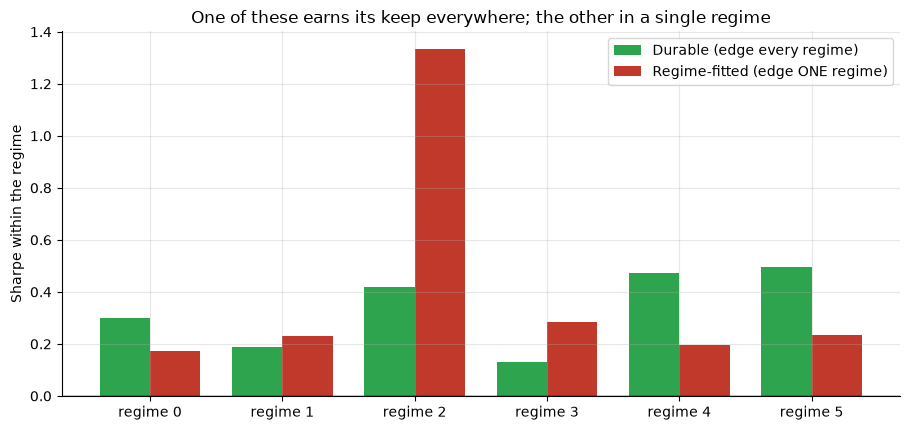

full-sample Sharpe  durable: 0.34   regime-fitted: 0.41


In [2]:
df, reg, truth = data.synthetic_regimes()
rs_dur = st.regime_sharpes(df['durable'], reg)
rs_fit = st.regime_sharpes(df['regime_fit'], reg)
x = np.arange(len(rs_dur))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
w = 0.38
ax.bar(x - w/2, rs_dur.values, w, color=GREEN, label='Durable (edge every regime)')
ax.bar(x + w/2, rs_fit.values, w, color=RED, label='Regime-fitted (edge ONE regime)')
ax.set_xticks(x); ax.set_xticklabels([f'regime {i}' for i in rs_dur.index])
ax.set_ylabel('Sharpe within the regime'); ax.axhline(0, c='k', lw=1)
ax.set_title('One of these earns its keep everywhere; the other in a single regime')
ax.legend(); plt.tight_layout(); plt.show()
print('full-sample Sharpe  durable:', round(st.sharpe(df['durable']),2),
      '  regime-fitted:', round(st.sharpe(df['regime_fit']),2))

Here's the trap in one line: the **regime-fitted** strategy's full-sample Sharpe (~0.41) is actually **higher** than the durable one's (~0.34). If you only ever looked at the headline number, you'd pick the *worse* strategy. The decade-by-decade bars give it away instantly — one bar towers, the rest are flat.

**Now the test that needs no chart-reading: drop each strategy's best decade and re-measure.** A durable edge shrugs it off; a one-era bet falls apart.

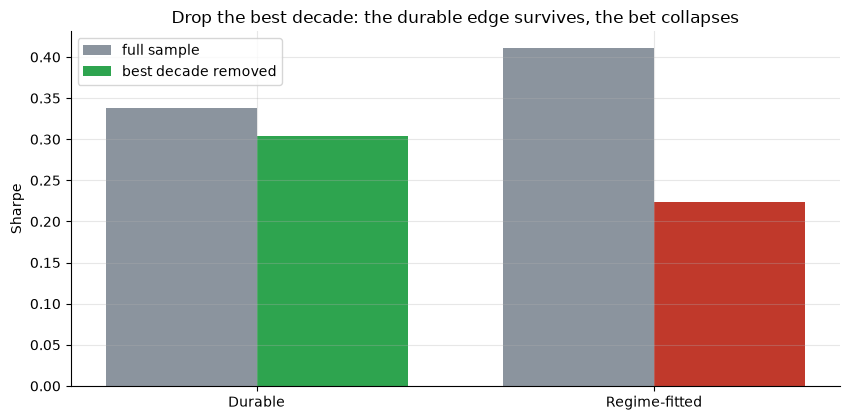

durable: 0.34 -> 0.30  (t 2.55 -> 2.14)
fitted : 0.41 -> 0.22  (t 3.05 -> 1.56)


In [3]:
dur = st.leave_hot_regime_out(df['durable'], reg)
fit = st.leave_hot_regime_out(df['regime_fit'], reg)
labels = ['Durable', 'Regime-fitted']
full = [dur['sharpe_full'], fit['sharpe_full']]
exhot = [dur['sharpe_ex_hot'], fit['sharpe_ex_hot']]
x = np.arange(2); w = 0.38
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(x - w/2, full, w, color=GREY, label='full sample')
ax.bar(x + w/2, exhot, w, color=[GREEN, RED], label='best decade removed')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('Sharpe')
ax.set_title('Drop the best decade: the durable edge survives, the bet collapses')
ax.legend(); plt.tight_layout(); plt.show()
print(f"durable: {dur['sharpe_full']:.2f} -> {dur['sharpe_ex_hot']:.2f}  "
      f"(t {dur['t_full']:.2f} -> {dur['t_ex_hot']:.2f})")
print(f"fitted : {fit['sharpe_full']:.2f} -> {fit['sharpe_ex_hot']:.2f}  "
      f"(t {fit['t_full']:.2f} -> {fit['t_ex_hot']:.2f})")

The durable strategy barely moves (0.34 → 0.3, still statistically significant). The regime-fitted one drops to ~0.22 and its significance evaporates — its 'edge' *was* the one decade. **The headline Sharpe lied; the drop-a-decade test told the truth.**

**Finally, the real tape.** Two well-worn strategies on US markets: a 12-month trend overlay and a static 60/40. How stable is each, decade by decade?

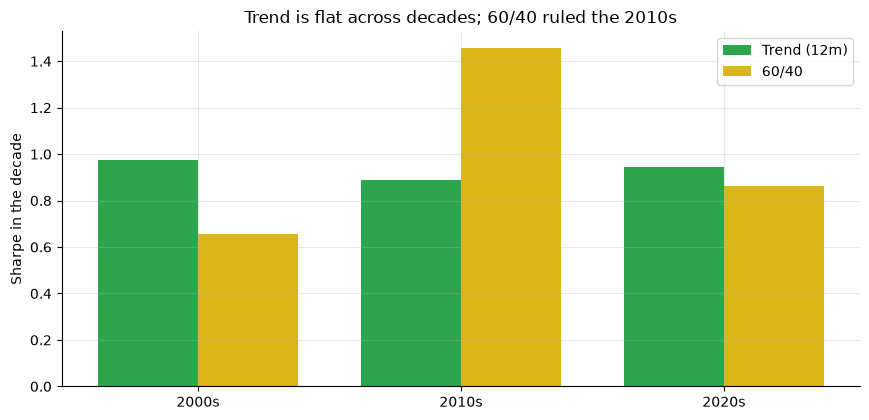

trend by decade: ['+0.97', '+0.89', '+0.94']
60/40 by decade: ['+0.66', '+1.46', '+0.86']


In [4]:
if HAVE_REAL:
    rets = data.load_real(fetch=False)
    trend = st.apply_trend(rets['equity'], lookback=12)
    mix = st.apply_6040(rets['equity'], rets['bond'])
    rt = st.regime_sharpes(trend, st.decade_label(trend.index))
    rm = st.regime_sharpes(mix, st.decade_label(mix.index))
    decs = sorted(set(rt.index) | set(rm.index))
    tv = [rt.get(d, np.nan) for d in decs]; mv = [rm.get(d, np.nan) for d in decs]
else:
    decs = [2000, 2010, 2020]
    tv = [0.97, 0.89, 0.94]
    mv = [0.66, 1.46, 0.86]
x = np.arange(len(decs)); w = 0.38
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x - w/2, tv, w, color=GREEN, label='Trend (12m)')
ax.bar(x + w/2, mv, w, color=AMBER, label='60/40')
ax.set_xticks(x); ax.set_xticklabels([f'{d}s' for d in decs])
ax.set_ylabel('Sharpe in the decade')
ax.set_title('Trend is flat across decades; 60/40 ruled the 2010s')
ax.legend(); plt.tight_layout(); plt.show()
print('trend by decade:', [f'{v:+.2f}' for v in tv])
print('60/40 by decade:', [f'{v:+.2f}' for v in mv])

The trend overlay is almost boringly stable — ~0.9 in every decade. The 60/40 clearly **ruled the 2010s** (1.46) versus the 2000s (0.66) and 2020s (0.86). On this short, three-decade tape both real strategies *survive* dropping their best decade — but the 60/40 leaned on one era far more than the trend did. The lens shows you exactly how much.

## 5 · The verdict

- **Signal — None.** This is a method, not a tradable effect; and on the real tape the decade differences are too small (three decades) to resolve from noise. The planted synthetic answer is a *machinery proof*, never market evidence.
- **Tradability — Mirage.** There's nothing to buy. It's a ruler for *other* strategies.
- **Did ruling one decade prove skill? — It depends, and now you can tell.** A strategy can post a great headline Sharpe and still be a one-era bet (we proved it on a planted fake). Split by decade and drop the best one, and the durable edges keep standing while the bets fall over.

## 6 · Could you actually trade it?

You don't trade a ruler — but it changes *what* you'll trade. Run any candidate strategy through it before you commit capital: if its edge halves (or vanishes) when you remove its best decade, you're looking at a regime bet, not a skill, and you should size it like one (or pass). The cheap discipline this study sells: **never accept a full-sample Sharpe without asking what's left after its luckiest era.** That one question would have saved a lot of 60/40 investors a lot of surprise in 2022.

## 7 · Going further 🚪

- **Pick the regimes that matter.** We split by calendar decade — but you can split by rate regime, by VIX level, by bull/bear. The lens is the same; the regimes are your hypothesis about *what* the strategy is really betting on.
- **Run it on the desk's other studies.** Take any 'Real' strategy on this bench and ask it the drop-best-decade question. Some will hold; some will wobble.
- **Longer history.** Our bond leg only lists from 2002. Swap in a longer Treasury total-return series and you get five-plus decades — and far more power in the gap test.

*Think your favourite backtest is skill? Fork this, split its returns by decade, and drop the best one. If the edge walks out the door with that decade, it was never yours.*